## This script does three professional things:

1. Uses Paracetamol as the target molecule (a recognisable pharmaceutical).

2. Label every axis with the specific atom (e.g., "C1", "O5") so the "influence" is traceable.

3. Calculates the Normalised Laplacian exactly as per my dissertation's mathematical framework.

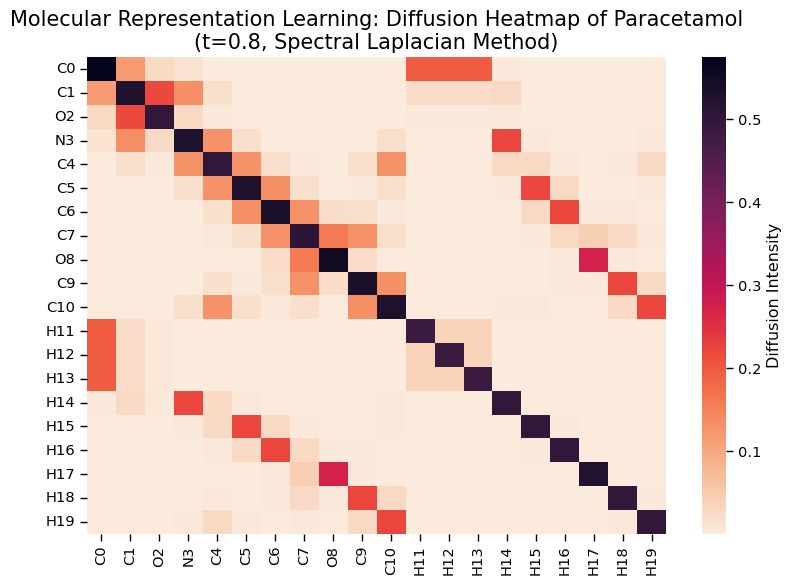

✅ Analysis Complete: 'molecular_diffusion_signature.png' has been saved.


In [19]:
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from scipy.linalg import expm

# 1. Chemical Setup: Paracetamol

# SMILES: CC(=O)NC1=CC=C(O)C=C1
smiles = "CC(=O)NC1=CC=C(O)C=C1"
mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)

# 2. Extract Atom Labels for the Plot
atom_labels = [f"{atom.GetSymbol()}{atom.GetIdx()}" for atom in mol.GetAtoms()]

#3. Graph Construction
adj = Chem.GetAdjacencyMatrix(mol)
G = nx.from_numpy_array(adj)

# 4. The MSc Dissertation Logic: Spectral Diffusion
# Matrix: L = I - D^(-1/2) * A * D^(-1/2)
L = nx.normalized_laplacian_matrix(G).toarray()

# Diffusion parameter (t)
# represents the scale of chemical interaction.
t = 0.8
diff_matrix = expm(-t * L)

# 5. High-Resolution Visualization
plt.figure(figsize=(8, 6))
sns.set_context("paper", font_scale=1.2)
sns.heatmap(
    diff_matrix,
    annot=False,
    cmap="rocket_r",
    xticklabels=atom_labels,
    yticklabels=atom_labels,
    cbar_kws={'label': 'Diffusion Intensity'}
)
plt.title(f"Molecular Representation Learning: Diffusion Heatmap of Paracetamol\n(t={t}, Spectral Laplacian Method)", fontsize=15)
plt.tight_layout()

# Save for your Portfolio
plt.savefig("molecular_diffusion_signature.png", dpi=300)
plt.show()

print("✅ Analysis Complete: 'molecular_diffusion_signature.png' has been saved.")


### The Task: Compare Paracetamol with Methyl-Paracetamol (adding one small group).

Create two molecules: Paracetamol and a modified version 


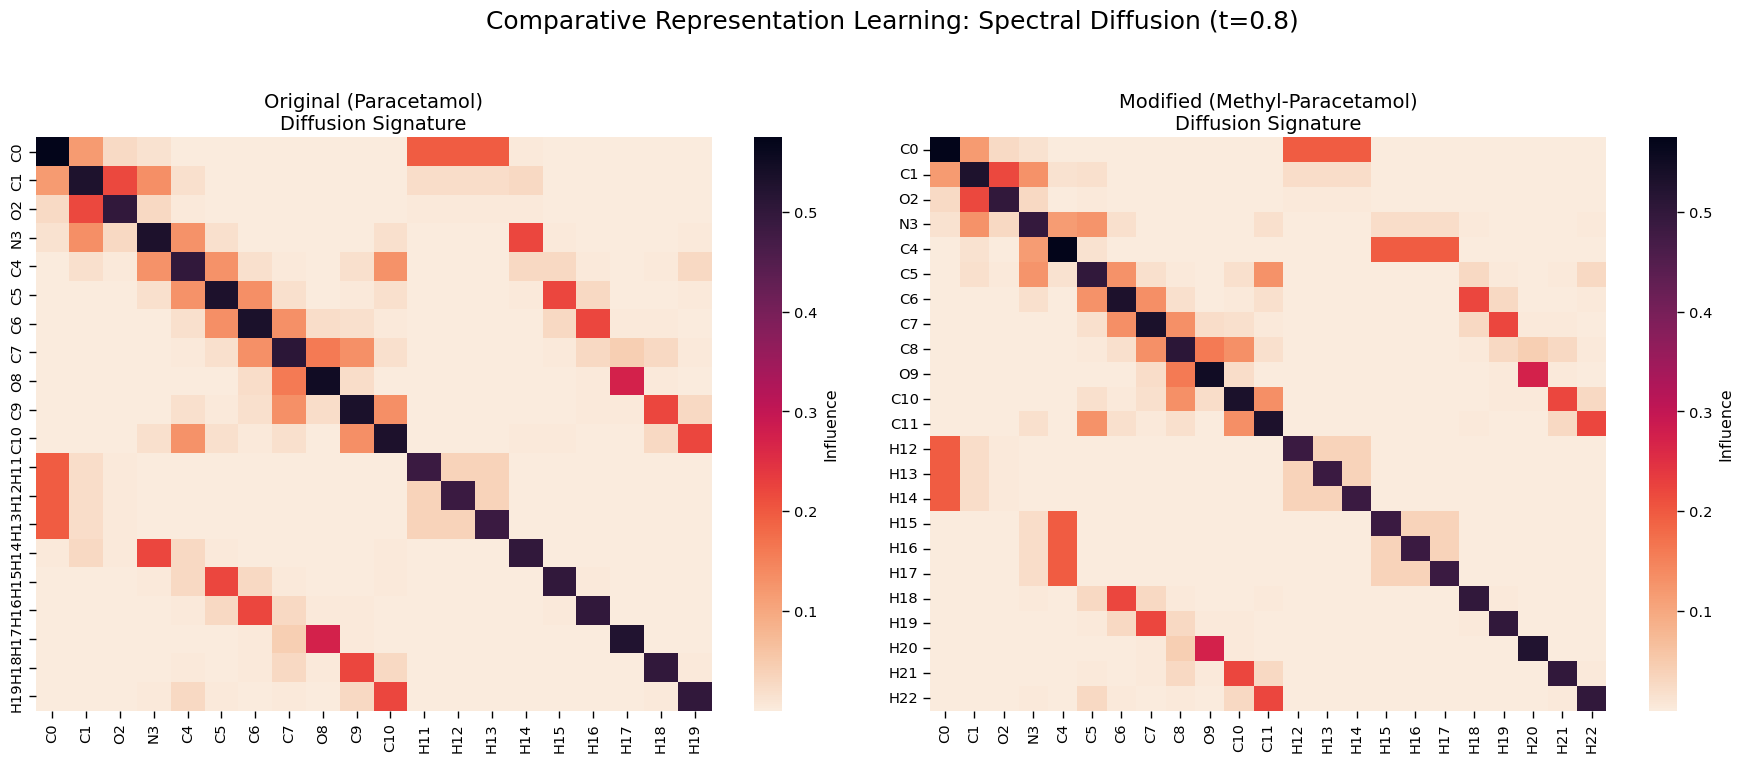

✅ Analysis Complete: 'molecular_comparison_study.png' saved.


In [21]:
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from scipy.linalg import expm

# 1. Define Molecules
mols = {
    "Original (Paracetamol)": Chem.MolFromSmiles("CC(=O)NC1=CC=C(O)C=C1"),
    "Modified (Methyl-Paracetamol)": Chem.MolFromSmiles("CC(=O)N(C)C1=CC=C(O)C=C1")
}

# 2. Setup Plotting Area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
t = 0.8 # Diffusion time

for i, (name, mol) in enumerate(mols.items()):
    # Add Hydrogens for accuracy
    mol = Chem.AddHs(mol)
    
    # Generate labels specific to THIS molecule
    labels = [f"{a.GetSymbol()}{a.GetIdx()}" for a in mol.GetAtoms()]
    
    # Calculate Diffusion (Your MSc Logic)
    adj = Chem.GetAdjacencyMatrix(mol)
    G = nx.from_numpy_array(adj)
    L = nx.normalized_laplacian_matrix(G).toarray()
    diff = expm(-t * L)
    
    # Plot on the specific subplot (axes[i])
    sns.heatmap(diff, ax=axes[i], cmap="rocket_r", 
                xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Influence'})
    axes[i].set_title(f"{name}\nDiffusion Signature", fontsize=14)

plt.suptitle(f"Comparative Representation Learning: Spectral Diffusion (t={t})", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 3. Save as a single comparison image (Best for GitHub/Portfolios)
plt.savefig("molecular_comparison_study.png", dpi=300)
plt.show()

print("✅ Analysis Complete: 'molecular_comparison_study.png' saved.")